# MDR-TS v16.2
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v16.2
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

Making a drift aware model, since 2023 appears to be a "hard" year for the base model


For other info see `MDR-TS-v1.0`

## 0. Imports

In [78]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from sklearn.decomposition import PCA

# Gradient Boosting (baseline model)
from xgboost import XGBRegressor

# PyTorch
import torch

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

imports loaded
using: cpu


## 1. Environment Setup

In [79]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [80]:
# Project paths
VERSION = "v16"
SUBVERSION = "v16.2"
RUN_NAME = "mdr_ts_v16_2"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v16/v16.2

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [81]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_6.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_6.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_6.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/test.csv


In [82]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 489

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


## 4. Data Sanity Checks

In [83]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
        "SMAP_sm_pm_interp_ema02",
        "V_rollmin_LST_modis_kobs30",
        "D_sin_DOY",
        "G_rain_sum_3d",
        "V_ema_G_API_kobs7",
        "V_rollmin_G_API_kobs30",
        "G_rain_sum_7d",
        "C_lag_LST_modis_kobs30",
        "C_lag_G_API_kobs1",
        "V_ema_G_API_kobs14",
        "V_rollmean_G_API_kobs14",
        "G_API",
        "A_pct_G_API",
        "V_rollcv_G_API_kobs30",
        "G_DSLR",
        "SMAP_ampm_diff_interp",
        "V_rollmax_G_API_kobs30",
        "V_rollmin_G_API_kobs7",
        "V_ema_G_API_kobs30",
        "V_rollmean_s2_b11_kobs7",
        "V_ema_LST_modis_kobs7",
        "C_smm_G_API_alpha0.85_n5",
        "C_lag_G_API_kobs5",
        "V_rollmean_G_API_kobs7",
        "C_lag_s2_b11_kobs30",
        "D_z_LST_modis",
        "A_d_G_API_kobs1",
        "V_rollcv_LST_modis_kobs30",
        "V_rollcv_G_API_kobs7",
        "V_rollstd_LST_modis_kobs30",
        "A_d_E_SAR_diff_kobs14",
        "C_lag_G_API_kobs6",
        "V_rollrng_F_NDMI_kobs7",
        "V_rollcv_G_API_kobs14",
        "C_lag_LST_modis_kobs6",
        "A_d_E_SAR_diff_kobs30",
        "A_d_LST_modis_kobs14",
        "SMAP_sm_am_interp_rollrange7",
        "V_rollstd_LST_modis_kobs14",
        "D_fft_ent_E_SAR_ratio_kobs30",
        "A_d_E_SAR_diff_kobs5",
        "SMAP_sm_pm_interp_rollrange7",
        "V_rollstd_F_NDMI_kobs7",
        "V_rollstd_E_SAR_ratio_kobs7",
        "V_rollrng_E_SAR_diff_kobs7",
        "V_rollstd_s2_b12_kobs7",
        "A_grad_E_SAR_diff_kobs14",
        "D_fft_dom_LST_modis_kobs30",
        "V_rollcv_s2_b12_kobs7",
        "A_d_E_SAR_ratio_kobs5",
        "D_fft_ent_LST_modis_kobs30",
        "V_rollstd_F_NDVI_kobs7",
        "A_grad_s2_b12_kobs7",
        "A_pct_F_NDVI",
        "A_d_s2_b12_kobs2",
        "A_grad_E_SAR_diff_kobs30",
        "A_d_F_NDVI_kobs2",
        "A_grad_E_SAR_diff_kobs7",
        "SMAP_sm_interp_rollrange7",
        "A_d_s2_b12_kobs7",
        "A_d_F_NDVI_kobs1",
        "V_rollcv_LST_modis_kobs14",
        "SMAP_sm_am_interp_rollstd7",
        "V_rollstd_SMAP_sm_interp_kobs7",
        "A_d_s2_b12_kobs5",
        "A_pct_SMAP_sm_interp",
        "SMAP_sm_am_interp_pctchg",
        "V_rollrng_SMAP_sm_interp_kobs7",
        "SMAP_sm_interp_pctchg",
        "A_d_E_SAR_diff_kobs2",
        "G_DSLR_isnan",
        "SMAP_sm_pm_interp_mask",
        "SMAP_sm_interp_mask",
        "SMAP_sm_am_interp_mask",
        "SMAP_sm_am_interp_diff1",
        "SMAP_sm_interp_rollstd7",
        "SMAP_sm_interp_diff1",
        "V_rollstd_E_SAR_diff_kobs7",
        "A_grad_s2_b12_kobs14",
        "A_d_E_SAR_ratio_kobs7",
        "A_grad_LST_modis_kobs14",
        "A_d_SMAP_sm_interp_kobs1",
        "SMAP_sm_pm_interp_pctchg",
        "A_grad_E_SAR_ratio_kobs7",
        "A_d_E_SAR_diff_kobs1",
        "A_d_E_SAR_diff_kobs7",
        "SMAP_sm_pm_interp_diff1",
        "A_d_F_NDVI_kobs5",
        "A_d_E_SAR_ratio_kobs2",
        "A_d_G_API_kobs5",
        "A_d_SMAP_sm_interp_kobs2",
        "D_fft_dom_E_SAR_ratio_kobs30",
        "SMAP_sm_pm_interp_rollstd7",
        "V_rollrng_s2_b12_kobs7",
        "V_rollrng_F_NDVI_kobs7",
        "A_d_SMAP_sm_interp_kobs14",
        "A_pct_E_SAR_ratio",
        "V_rollstd_SMAP_sm_interp_kobs30",
        "A_d_E_SAR_ratio_kobs1",
        "A_pct_LST_modis",
        "A_grad_SMAP_sm_interp_kobs14",
        "A_pct_E_SAR_diff",
        "SMAP_sm_interp_grad7",
        "A_grad_SMAP_sm_interp_kobs7",
        "A_d_LST_modis_kobs1",
        "V_rollcv_E_SAR_diff_kobs7",
        "A_d_s2_b11_kobs5",
        "V_rollstd_LST_modis_kobs7",
]

expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 108
  Target:   soil_moisture_5cm


In [84]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap
[WARN] station Touchet_WA_824: missing split data (train=3311, val=0, test=170)

[WARNING] 1 station(s) have temporal leakage or split issues.


In [85]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Quinault:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Spokane:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Touchet_WA_824:
    train max date: 2020-10-28 00:00:00
    val   min date: NaT


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [86]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     16972
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 00:00:00 -- 2021-09-23 00:00:00

VAL
  rows:     2919
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-09-24 00:00:00 -- 2023-11-12 00:00:00

TEST
  rows:     2829
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-11-13 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [87]:
def station_set(df):
    return set(df["station_id"].dropna().unique())

train_st = station_set(train_df)
val_st   = station_set(val_df)
test_st  = station_set(test_df)

print("Stations count:")
print("  train:", len(train_st))
print("  val  :", len(val_st))
print("  test :", len(test_st))

print("\nStations in train but NOT in val:", sorted(train_st - val_st)[:20])
print("Stations in train but NOT in test:", sorted(train_st - test_st)[:20])
print("Stations in val but NOT in train:", sorted(val_st - train_st)[:20])
print("Stations in test but NOT in train:", sorted(test_st - train_st)[:20])

Stations count:
  train: 5
  val  : 4
  test : 5

Stations in train but NOT in val: ['Touchet_WA_824']
Stations in train but NOT in test: []
Stations in val but NOT in train: []
Stations in test but NOT in train: []


In [88]:
train_df["date"] = pd.to_datetime(train_df["date"], errors="coerce")
train_df["year"] = train_df["date"].dt.year

max_year = train_df["year"].max()
beta = 0.35  # tune later

weights = np.exp(beta * (train_df["year"] - max_year))
weights = weights / weights.mean()

train_df["sample_weight"] = weights

In [89]:
def add_drift_features(df, date_col="date", ref_min_year=None, ref_max_year=None):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df["year"] = df[date_col].dt.year.astype(float)

    if ref_min_year is None:
        ref_min_year = float(df["year"].min())
    if ref_max_year is None:
        ref_max_year = float(df["year"].max())

    denom = (ref_max_year - ref_min_year) if (ref_max_year > ref_min_year) else 1.0
    df["year_frac"] = (df["year"] - ref_min_year) / denom

    theta = 2 * np.pi * df["year_frac"]
    df["sin_year"] = np.sin(theta)
    df["cos_year"] = np.cos(theta)

    return df, ref_min_year, ref_max_year

train_df_d, y0, y1 = add_drift_features(train_df, ref_min_year=None, ref_max_year=None)
val_df_d, _, _     = add_drift_features(val_df,   ref_min_year=y0, ref_max_year=y1)
test_df_d, _, _    = add_drift_features(test_df,  ref_min_year=y0, ref_max_year=y1)

DRIFT_COLS = ["year_frac", "sin_year", "cos_year"]  # keep it simple
FEATURE_COLS_D = FEATURE_COLS + DRIFT_COLS

print("Added drift features:", DRIFT_COLS)
print("New feature count:", len(FEATURE_COLS_D))
print("Train year range:", y0, "to", y1)

Added drift features: ['year_frac', 'sin_year', 'cos_year']
New feature count: 111
Train year range: 2011.0 to 2021.0


In [90]:
trainval_df_d = pd.concat([train_df_d, val_df_d], axis=0).reset_index(drop=True)

X_trainval_d = trainval_df_d[FEATURE_COLS_D].copy()
y_trainval_d = trainval_df_d[TARGET_COL].copy()

X_test_d = test_df_d[FEATURE_COLS_D].copy()
y_test_d = test_df_d[TARGET_COL].copy()

print("\nDRIFT matrices:")
print("  X_trainval_d:", X_trainval_d.shape)
print("  X_test_d:    ", X_test_d.shape)


DRIFT matrices:
  X_trainval_d: (19891, 111)
  X_test_d:     (2829, 111)


## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [91]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()
w_train = train_df["sample_weight"].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  weights: {w_train.shape}")

Feature matrix shapes:
  X_train: (16972, 108)
  X_val:   (2919, 108)
  X_test:  (2829, 108)
  y_train: (16972,)
  weights: (16972,)


In [92]:
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

X_trainval = trainval_df[FEATURE_COLS].copy()
y_trainval = trainval_df[TARGET_COL].copy()

print("\nBaseline train+val shapes:")
print("  X_trainval:", X_trainval.shape)
print("  y_trainval:", y_trainval.shape)


Baseline train+val shapes:
  X_trainval: (19891, 108)
  y_trainval: (19891,)


### 6.2 Feature Overview

In [93]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary # interactive sheet

,mean,std,min,max
A_pct_G_API,76.666423,9980.235936,-0.100000,1.300000e+06
C_smm_G_API_alpha0.85_n5,135.545656,157.525647,0.000000,1.168583e+03
V_rollmax_G_API_kobs30,74.219122,72.224672,0.225530,4.087574e+02
C_lag_G_API_kobs1,43.039290,50.742830,0.000000,4.087574e+02
G_API,43.040359,50.740737,0.000000,4.087574e+02
...,...,...,...,...
V_rollstd_E_SAR_diff_kobs7,0.001309,0.003050,0.000000,4.728213e-02
A_grad_SMAP_sm_interp_kobs14,-0.000013,0.002882,-0.014076,1.960790e-02
A_grad_E_SAR_diff_kobs7,0.000005,0.001162,-0.013485,1.495192e-02
A_grad_E_SAR_diff_kobs14,0.000005,0.000749,-0.009747,7.147361e-03


### 6.4 Baseline Model Definition

In [94]:
DEEP_SEARCH = 40

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

In [95]:
XGB_PARAMS = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,

    subsample=0.9,
    reg_lambda=2.0,
    reg_alpha=0.05,
    n_estimators=4000,
    min_child_weight=3,
    max_depth=7,
    learning_rate=0.05,
    gamma=0.0,
    colsample_bytree=0.75,
)

model_xgb = XGBRegressor(**XGB_PARAMS)

MODEL_CONFIG_FINAL = model_xgb.get_params()

print("\nUsing fixed XGB params:")
for k in [
    "n_estimators","max_depth","learning_rate","min_child_weight","gamma",
    "subsample","colsample_bytree","reg_alpha","reg_lambda"
]:
    print(f"  {k}: {MODEL_CONFIG_FINAL.get(k)}")


Using fixed XGB params:
  n_estimators: 4000
  max_depth: 7
  learning_rate: 0.05
  min_child_weight: 3
  gamma: 0.0
  subsample: 0.9
  colsample_bytree: 0.75
  reg_alpha: 0.05
  reg_lambda: 2.0


In [96]:
print("Weight stats:")
print(pd.Series(weights).describe())
print("Min year weight:", weights[train_df["year"] == train_df["year"].min()].mean())
print("Max year weight:", weights[train_df["year"] == train_df["year"].max()].mean())

Weight stats:
count    16972.000000
mean         1.000000
std          0.929495
min          0.103658
25%          0.296218
50%          0.596511
75%          1.704620
max          3.432683
Name: year, dtype: float64
Min year weight: 0.10365803407472972
Max year weight: 3.4326826475342025


In [97]:
assert list(X_trainval.columns) == list(X_train.columns), "Baseline: X_trainval and X_train columns differ"
assert list(X_trainval.columns) == list(X_val.columns),   "Baseline: X_trainval and X_val columns differ"
assert list(X_trainval.columns) == list(X_test.columns),  "Baseline: X_trainval and X_test columns differ"

assert X_trainval.shape[0] == len(y_trainval)
assert X_train.shape[0] == len(y_train)
assert X_val.shape[0] == len(y_val)
assert X_test.shape[0] == len(y_test)

print("Baseline sanity checks passed.")

Baseline sanity checks passed.


In [98]:
xgb_params = model_xgb.get_params()
xgb_trainval_model = XGBRegressor(**xgb_params)
xgb_trainval_model.fit(X_trainval, y_trainval, verbose=1000)

yhat_train_tv = xgb_trainval_model.predict(X_train)
yhat_val_tv   = xgb_trainval_model.predict(X_val)
yhat_test_tv  = xgb_trainval_model.predict(X_test)

print("\nXGB (baseline train+val) predictions generated")
print("  yhat_train_tv:", yhat_train_tv.shape)
print("  yhat_val_tv:  ", yhat_val_tv.shape)
print("  yhat_test_tv: ", yhat_test_tv.shape)

print("\nRMSE (baseline train+val fit)")
print("  train:", rmse(y_train, yhat_train_tv))
print("  val:  ", rmse(y_val,   yhat_val_tv), "  <-- seen during training")
print("  test: ", rmse(y_test,  yhat_test_tv))


XGB (baseline train+val) predictions generated
  yhat_train_tv: (16972,)
  yhat_val_tv:   (2919,)
  yhat_test_tv:  (2829,)

RMSE (baseline train+val fit)
  train: 0.0017808117322769817
  val:   0.001483578165243164   <-- seen during training
  test:  0.04775827335667276


In [99]:
xgb_params = model_xgb.get_params() if "model_xgb" in globals() else XGB_PARAMS
model_xgb_drift = XGBRegressor(**xgb_params)

model_xgb_drift.fit(X_trainval_d, y_trainval_d, verbose=1000)

yhat_test_drift = model_xgb_drift.predict(X_test_d)

print("\nDRIFT Test R2:", float(r2_score(y_test_d, yhat_test_drift)))
print("DRIFT Test bias (true-pred):", float(np.mean(np.asarray(y_test_d).ravel() - np.asarray(yhat_test_drift).ravel())))

diag_d = test_df_d.copy()
diag_d["year"] = pd.to_datetime(diag_d["date"], errors="coerce").dt.year
diag_d["y"] = np.asarray(y_test_d).ravel()
diag_d["pred"] = np.asarray(yhat_test_drift).ravel()

d2023 = diag_d[diag_d["year"] == 2023].copy()

if len(d2023) >= 2:
    r2_2023 = float(r2_score(d2023["y"], d2023["pred"]))
    a, b = np.polyfit(d2023["pred"], d2023["y"], 1)
    print("\nDRIFT 2023 R2:", r2_2023)
    print("DRIFT 2023 slope:", float(a), "intercept:", float(b))
else:
    print("\nNo 2023 rows found in DRIFT test slice.")


DRIFT Test R2: 0.7909002589327576
DRIFT Test bias (true-pred): 0.003315292370128691

DRIFT 2023 R2: -0.10103252644386562
DRIFT 2023 slope: 0.7022743962865607 intercept: 0.10125986103967102


## 7. Training Loop

In [100]:
RF_PARAMS = dict(
    n_estimators=1600,
    min_samples_split=20,
    min_samples_leaf=2,
    max_features="sqrt",
    max_depth=None,
    n_jobs=-1,
    random_state=SEED,
    bootstrap=True,
)

model_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(**RF_PARAMS)),
])

MODEL_CONFIG_RF = {
    "n_estimators": model_rf.named_steps["model"].n_estimators,
    "max_depth": model_rf.named_steps["model"].max_depth,
    "min_samples_leaf": model_rf.named_steps["model"].min_samples_leaf,
    "min_samples_split": model_rf.named_steps["model"].min_samples_split,
    "max_features": model_rf.named_steps["model"].max_features,
    "n_jobs": model_rf.named_steps["model"].n_jobs,
    "random_state": model_rf.named_steps["model"].random_state,
    "bootstrap": model_rf.named_steps["model"].bootstrap,
}

print("\nUsing fixed RF params:")
for k, v in MODEL_CONFIG_RF.items():
    print(f"  {k}: {v}")


Using fixed RF params:
  n_estimators: 1600
  max_depth: None
  min_samples_leaf: 2
  min_samples_split: 20
  max_features: sqrt
  n_jobs: -1
  random_state: 42
  bootstrap: True


In [101]:
model_rf.fit(X_train, y_train)

yhat_train_rf = model_rf.predict(X_train)
yhat_val_rf   = model_rf.predict(X_val)
yhat_test_rf  = model_rf.predict(X_test)

print("\nRF predictions generated")
print("  yhat_train_rf:", yhat_train_rf.shape)
print("  yhat_val_rf:  ", yhat_val_rf.shape)
print("  yhat_test_rf: ", yhat_test_rf.shape)

print("\nRMSE")
print("  train:", rmse(y_train, yhat_train_rf))
print("  val:  ", rmse(y_val,   yhat_val_rf))
print("  test: ", rmse(y_test,  yhat_test_rf))


RF predictions generated
  yhat_train_rf: (16972,)
  yhat_val_rf:   (2919,)
  yhat_test_rf:  (2829,)

RMSE
  train: 0.01755256699183563
  val:   0.0395998019451833
  test:  0.04575991321425719


In [102]:
y_train_np = np.asarray(y_train).ravel()
y_val_np   = np.asarray(y_val).ravel()
y_test_np  = np.asarray(y_test).ravel()

yhat_train_np_base = np.asarray(yhat_train_tv).ravel()
yhat_val_np_base   = np.asarray(yhat_val_tv).ravel()
yhat_test_np_base  = np.asarray(yhat_test_tv).ravel()

print("\nBaseline train+val XGB metrics:")
print("  test R2:", float(r2_score(y_test_np, yhat_test_np_base)))
print("  test bias:", float(np.mean(y_test_np - yhat_test_np_base)))


Baseline train+val XGB metrics:
  test R2: 0.7392641223022478
  test bias: 0.013022661610305332


In [103]:
yhat_train_rf_np = np.asarray(yhat_train_rf).ravel()
yhat_val_rf_np   = np.asarray(yhat_val_rf).ravel()
yhat_test_rf_np  = np.asarray(yhat_test_rf).ravel()

print("Base RF test R2:", float(r2_score(y_test_np, yhat_test_rf_np)))
print("Base RF val  R2:", float(r2_score(y_val_np,  yhat_val_rf_np)))
print("Base RF test bias (true - pred):", float(np.mean(y_test_np - yhat_test_rf_np)))

Base RF test R2: 0.760627671085639
Base RF val  R2: 0.8454137406883705
Base RF test bias (true - pred): 0.01399420259321183


## Calibration

In [104]:
X_train_d = train_df_d[FEATURE_COLS_D].copy()
y_train_d = train_df_d[TARGET_COL].copy()

X_val_d = val_df_d[FEATURE_COLS_D].copy()
y_val_d = val_df_d[TARGET_COL].copy()

X_test_d = test_df_d[FEATURE_COLS_D].copy()
y_test_d = test_df_d[TARGET_COL].copy()

print("Baseline shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Drift shapes   :", X_train_d.shape, X_val_d.shape, X_test_d.shape)

Baseline shapes: (16972, 108) (2919, 108) (2829, 108)
Drift shapes   : (16972, 111) (2919, 111) (2829, 111)


In [105]:
xgb_params = model_xgb.get_params()
xgb_base_train = XGBRegressor(**xgb_params)
xgb_base_train.fit(X_train, y_train, verbose=0)

pred_base = {
    "val":  np.asarray(xgb_base_train.predict(X_val)).ravel(),
    "test": np.asarray(xgb_base_train.predict(X_test)).ravel(),
}

xgb_drift_train = XGBRegressor(**xgb_params)
xgb_drift_train.fit(X_train_d, y_train_d, verbose=0)

pred_drift = {
    "val":  np.asarray(xgb_drift_train.predict(X_val_d)).ravel(),
    "test": np.asarray(xgb_drift_train.predict(X_test_d)).ravel(),
}

y_val_np  = np.asarray(y_val).ravel()
y_test_np = np.asarray(y_test).ravel()

y_val_d_np  = np.asarray(y_val_d).ravel()
y_test_d_np = np.asarray(y_test_d).ravel()

print("Uncalibrated (TRAIN only) metrics")
print("Baseline: val R2", float(r2_score(y_val_np, pred_base["val"])), "test R2", float(r2_score(y_test_np, pred_base["test"])))
print("Drift   : val R2", float(r2_score(y_val_d_np, pred_drift["val"])), "test R2", float(r2_score(y_test_d_np, pred_drift["test"])))

Uncalibrated (TRAIN only) metrics
Baseline: val R2 0.8364719587133143 test R2 0.6917631955323562
Drift   : val R2 0.8752834483957136 test R2 0.7591182844661051


In [106]:
def fit_best_ridge_calibrator(yhat_val, y_val, alphas=None):
    if alphas is None:
        alphas = np.logspace(-6, 3, 15)
    best = None
    for a in alphas:
        cal = Ridge(alpha=a)
        cal.fit(yhat_val.reshape(-1, 1), y_val)
        yhat_val_cal = cal.predict(yhat_val.reshape(-1, 1))
        r2_val = r2_score(y_val, yhat_val_cal)
        if (best is None) or (r2_val > best["r2_val"]):
            best = {
                "alpha": float(a),
                "r2_val": float(r2_val),
                "slope": float(cal.coef_[0]),
                "intercept": float(cal.intercept_),
                "model": cal,
            }
    return best

best_base = fit_best_ridge_calibrator(pred_base["val"], y_val_np)
best_drift = fit_best_ridge_calibrator(pred_drift["val"], y_val_d_np)

print("Best Ridge calibrator (Baseline)")
print("  alpha    :", best_base["alpha"])
print("  slope a  :", best_base["slope"])
print("  intercept:", best_base["intercept"])
print("  val R2   :", best_base["r2_val"])

print("\nBest Ridge calibrator (Drift)")
print("  alpha    :", best_drift["alpha"])
print("  slope a  :", best_drift["slope"])
print("  intercept:", best_drift["intercept"])
print("  val R2   :", best_drift["r2_val"])

Best Ridge calibrator (Baseline)
  alpha    : 1.9306977288832496e-05
  slope a  : 0.9657086730003357
  intercept: 0.024504289031028748
  val R2   : 0.8678976538035807

Best Ridge calibrator (Drift)
  alpha    : 1.9306977288832496e-05
  slope a  : 0.9759376645088196
  intercept: 0.00891295075416565
  val R2   : 0.877161517817739


In [107]:
def apply_cal(cal_model, yhat):
    return np.asarray(cal_model.predict(np.asarray(yhat).reshape(-1, 1))).ravel()

pred_base_test_cal = apply_cal(best_base["model"], pred_base["test"])
pred_drift_test_cal = apply_cal(best_drift["model"], pred_drift["test"])

print("TEST performance (TRAIN model + VAL calibrator)")
print("\nBaseline:")
print("  uncal test R2:", float(r2_score(y_test_np, pred_base["test"])))
print("  cal   test R2:", float(r2_score(y_test_np, pred_base_test_cal)))
print("  uncal bias   :", float(np.mean(y_test_np - pred_base["test"])))
print("  cal   bias   :", float(np.mean(y_test_np - pred_base_test_cal)))

print("\nDrift:")
print("  uncal test R2:", float(r2_score(y_test_d_np, pred_drift["test"])))
print("  cal   test R2:", float(r2_score(y_test_d_np, pred_drift_test_cal)))
print("  uncal bias   :", float(np.mean(y_test_d_np - pred_drift["test"])))
print("  cal   bias   :", float(np.mean(y_test_d_np - pred_drift_test_cal)))

TEST performance (TRAIN model + VAL calibrator)

Baseline:
  uncal test R2: 0.6917631955323562
  cal   test R2: 0.7270425505949906
  uncal bias   : 0.01702194003896184
  cal   bias   : -0.0006406663504220769

Drift:
  uncal test R2: 0.7591182844661051
  cal   test R2: 0.7610994444192057
  uncal bias   : 0.002911224245155983
  cal   bias   : -0.0008613588124850727


### 7.2 Metrics

In [108]:
def metrics_block(split_name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    return {
        "split": split_name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
        "bias_mean(true-pred)": float(np.mean(y_true - y_pred)),
    }

def make_before_after_table(y_train, y_val, y_test,
                            yhat_train, yhat_val, yhat_test,
                            yhat_train_cal, yhat_val_cal, yhat_test_cal,
                            title_suffix=""):
    results_before = pd.DataFrame([
        metrics_block("train", y_train, yhat_train),
        metrics_block("val",   y_val,   yhat_val),
        metrics_block("test",  y_test,  yhat_test),
    ])

    results_after = pd.DataFrame([
        metrics_block("train", y_train, yhat_train_cal),
        metrics_block("val",   y_val,   yhat_val_cal),
        metrics_block("test",  y_test,  yhat_test_cal),
    ])

    print(f"BEFORE{title_suffix}:")
    display(results_before)

    print(f"\nAFTER (Ridge post-hoc calibrated){title_suffix}:")
    display(results_after)

    return results_before, results_after

In [109]:
yhat_train_base = np.asarray(xgb_base_train.predict(X_train)).ravel()
yhat_val_base   = np.asarray(xgb_base_train.predict(X_val)).ravel()
yhat_test_base  = np.asarray(xgb_base_train.predict(X_test)).ravel()

y_train_np = np.asarray(y_train).ravel()
y_val_np   = np.asarray(y_val).ravel()
y_test_np  = np.asarray(y_test).ravel()

In [110]:
best_base = fit_best_ridge_calibrator(yhat_val_base, y_val_np)
cal_base = best_base["model"]

yhat_train_cal_base = cal_base.predict(yhat_train_base.reshape(-1, 1)).ravel()
yhat_val_cal_base   = cal_base.predict(yhat_val_base.reshape(-1, 1)).ravel()
yhat_test_cal_base  = cal_base.predict(yhat_test_base.reshape(-1, 1)).ravel()

In [111]:
results_before_base, results_after_base = make_before_after_table(
    y_train_np,
    y_val_np,
    y_test_np,
    yhat_train_base,
    yhat_val_base,
    yhat_test_base,
    yhat_train_cal_base,
    yhat_val_cal_base,
    yhat_test_cal_base,
    title_suffix=" (baseline)"
)

BEFORE (baseline):


,split,MAE,RMSE,R2,bias_mean(true-pred)
0,train,0.001181,0.001738,0.999711,-8.976808e-07
1,val,0.030887,0.040729,0.836472,1.754098e-02
2,test,0.040087,0.051927,0.691763,1.702194e-02



AFTER (Ridge post-hoc calibrated) (baseline):


,split,MAE,RMSE,R2,bias_mean(true-pred)
0,train,0.017823,0.018269,0.968080,-1.782269e-02
1,val,0.028557,0.036607,0.867898,-6.766516e-09
2,test,0.039309,0.048865,0.727043,-6.406664e-04


### 7.3 Diagnostics

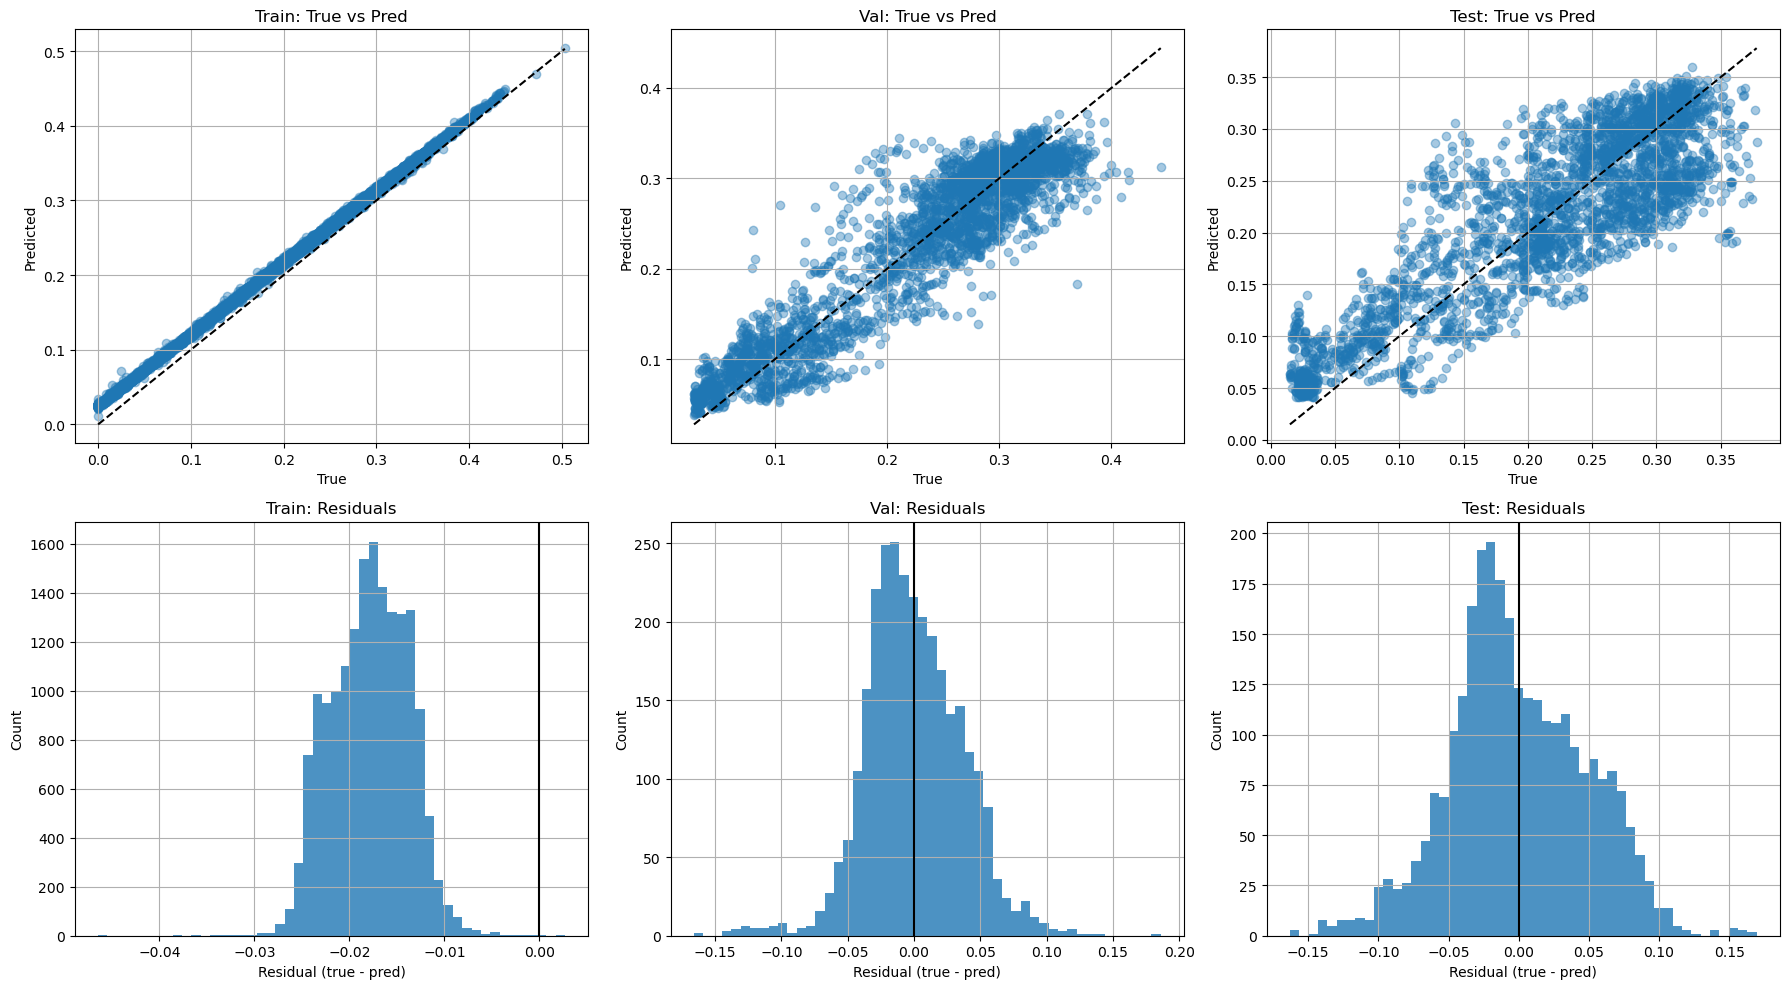

In [112]:
def _to_1d(a):
    if hasattr(a, "to_numpy"):
        a = a.to_numpy()
    a = np.asarray(a).ravel()
    return a

def scatter_plot(ax, y_true, y_pred, title):
    y_true = _to_1d(y_true)
    y_pred = _to_1d(y_pred)

    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[m]
    y_pred = y_pred[m]

    ax.scatter(y_true, y_pred, alpha=0.4)
    lo = float(np.min(y_true)) if len(y_true) else 0.0
    hi = float(np.max(y_true)) if len(y_true) else 1.0
    ax.plot([lo, hi], [lo, hi], color="black", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)

def residual_hist(ax, y_true, y_pred, title):
    y_true = _to_1d(y_true)
    y_pred = _to_1d(y_pred)

    m = np.isfinite(y_true) & np.isfinite(y_pred)
    resid = y_true[m] - y_pred[m]

    ax.hist(resid, bins=50, alpha=0.8)
    ax.axvline(0, color="black")
    ax.set_title(title)
    ax.set_xlabel("Residual (true - pred)")
    ax.set_ylabel("Count")
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_plot(axes[0, 0], y_train_np, yhat_train_cal_base, "Train: True vs Pred")
scatter_plot(axes[0, 1], y_val_np,   yhat_val_cal_base,   "Val: True vs Pred")
scatter_plot(axes[0, 2], y_test_np,  yhat_test_cal_base,  "Test: True vs Pred")

residual_hist(axes[1, 0], y_train_np, yhat_train_cal_base, "Train: Residuals")
residual_hist(axes[1, 1], y_val_np,   yhat_val_cal_base,   "Val: Residuals")
residual_hist(axes[1, 2], y_test_np,  yhat_test_cal_base,  "Test: Residuals")

plt.tight_layout()
plt.show()

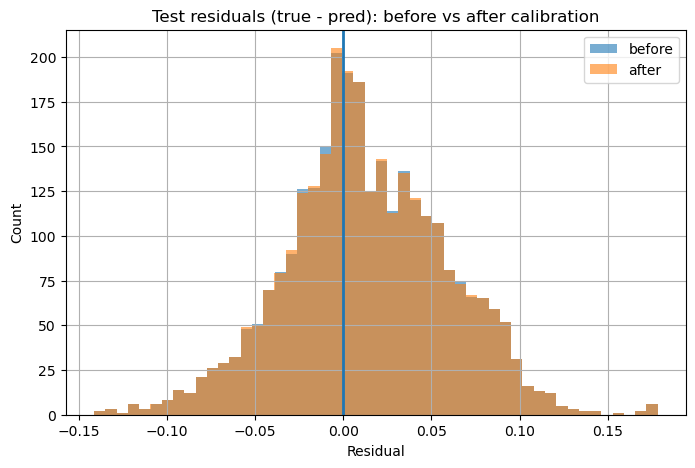

In [ ]:
y_true = _to_1d(y_test_np)
yhat_before = _to_1d(yhat_test_base)
yhat_after  = _to_1d(yhat_test_cal_base)

mask = np.isfinite(y_true) & np.isfinite(yhat_before) & np.isfinite(yhat_after)

res_before = y_true[mask] - yhat_before[mask]
res_after  = y_true[mask] - yhat_after[mask]

plt.figure(figsize=(8, 5))
plt.hist(res_before, bins=50, alpha=0.6, label="before")
plt.hist(res_after,  bins=50, alpha=0.6, label="after")
plt.axvline(0, linewidth=2)
plt.title("Test residuals (true - pred): before vs after calibration")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

print("Before bias:", float(np.mean(res_before)))
print("After bias :", float(np.mean(res_after)))
print("Before std :", float(np.std(res_before)))
print("After std  :", float(np.std(res_after)))

### 7.4 Feature Importance

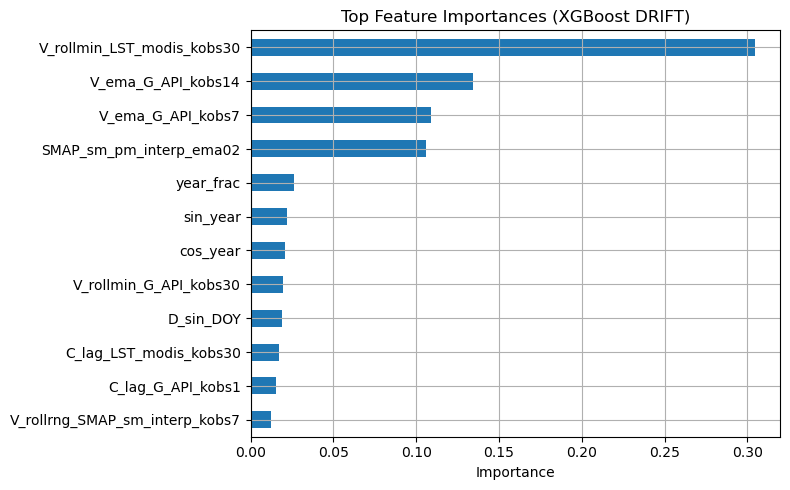

V_rollmin_LST_modis_kobs30    0.304493
V_ema_G_API_kobs14            0.134385
V_ema_G_API_kobs7             0.108640
SMAP_sm_pm_interp_ema02       0.106087
year_frac                     0.025956
                                ...   
SMAP_sm_pm_interp_mask        0.000034
A_d_SMAP_sm_interp_kobs1      0.000005
SMAP_sm_interp_mask           0.000000
SMAP_sm_am_interp_mask        0.000000
G_DSLR_isnan                  0.000000
Length: 111, dtype: float32

In [115]:
importances = pd.Series(model_xgb_drift.feature_importances_, index=FEATURE_COLS_D).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances (XGBoost DRIFT)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## 8. Evaluation

### 8.1 Test Metrics

In [ ]:
test_metrics = {
    "MAE":  mean_absolute_error(y_test, yhat_test_cal),
    "RMSE": rmse(y_test, yhat_test_cal),
    "R2":   r2_score(y_test, yhat_test_cal),
    "n":    len(y_test),
}

pd.DataFrame([test_metrics])

,MAE,RMSE,R2,n
0,0.03715,0.047756,0.739289,2829


### 8.2 Test Prediction Scatter

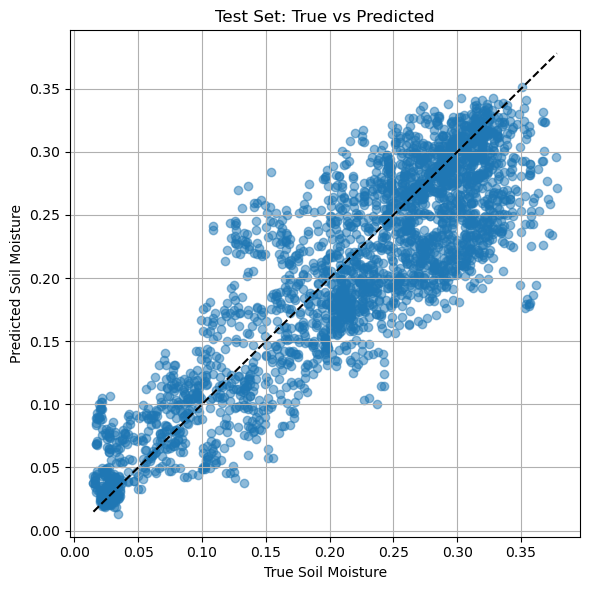

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test_cal, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Test Set: True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### 8.3 Bias

In [ ]:
print(
    f"""
Residual diagnostics
--------------------
VAL  residual mean : {float((y_val.values - yhat_val_cal).mean()): .6f}
TEST residual mean : {float((y_test.values - yhat_test_cal).mean()): .6f}

Prediction ranges
-----------------
VAL  range : {float(yhat_val_cal.min()): .6f} to {float(yhat_val_cal.max()): .6f}
TEST range : {float(yhat_test_cal.min()): .6f} to {float(yhat_test_cal.max()): .6f}
"""
)


Residual diagnostics
--------------------
VAL  residual mean :  0.000000
TEST residual mean :  0.013007

Prediction ranges
-----------------
VAL  range :  0.026570 to  0.439037
TEST range :  0.013397 to  0.351117



## 9. Analysis

In [122]:
def slope_stats(y_true, y_pred):
    y_true = np.asarray(y_true).ravel().astype(float)
    y_pred = np.asarray(y_pred).ravel().astype(float)
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[m]; y_pred = y_pred[m]
    if len(y_true) < 2 or np.std(y_pred) == 0:
        return np.nan, np.nan, np.nan
    a, b = np.polyfit(y_pred, y_true, 1)  # y ≈ a*pred + b
    return float(r2_score(y_true, y_pred)), float(a), float(b)

years = pd.to_datetime(test_df["date"], errors="coerce").dt.year.to_numpy()
mask_2023 = years == 2023

y_2023 = np.asarray(y_test).ravel()[mask_2023]

pred_base_2023 = np.asarray(yhat_test_tv).ravel()[mask_2023]
pred_drift_2023 = np.asarray(yhat_test_drift).ravel()[mask_2023]

r2_b, a_b, b_b = slope_stats(y_2023, pred_base_2023)
r2_d, a_d, b_d = slope_stats(y_2023, pred_drift_2023)

print("2023 sample count:", int(mask_2023.sum()))
print("\nBaseline (train+val) 2023:")
print("  R2   :", r2_b)
print("  slope:", a_b, "intercept:", b_b)

print("\nDrift 2023:")
print("  R2   :", r2_d)
print("  slope:", a_d, "intercept:", b_d)

2023 sample count: 79

Baseline (train+val) 2023:
  R2   : -0.47416370258567464
  slope: 0.5405249887847118 intercept: 0.15005814028181916

Drift 2023:
  R2   : -0.10103252644386562
  slope: 0.7022743962865607 intercept: 0.10125986103967102


---

_Jakob Balkovec_